In [79]:
import igraph as ig
import networkx as nx
import csv
import pandas as pd
import dask.dataframe as dd 
import matplotlib.pyplot as plt


# Min

In [ ]:

# Min

In [ ]:
cp_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/dataflow/montage-pegasus-2mass-2deg-4node/"
df1 = dd.read_parquet(cp_dir+"lvl1/*.parquet")
df2 = dd.read_parquet(cp_dir+"lvl2/*.parquet")
df3 = dd.read_parquet(cp_dir+"lvl3/*.parquet")

fhash_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint/fhash/montage-pegasus-2mass-2deg-4node/*.parquet"
fhash = dd.read_parquet(fhash_dir)
fhash["mount_point"] = fhash["mount_point"].where(fhash["mount_point"].str.startswith("/"), "/p/lustre3")

df3_with_mount = df3.merge(
    fhash[['hash', 'mount_point']], 
    left_on='fhash', 
    right_on='hash', 
    how='left'
)
df3_new = df3_with_mount.query("mount_point == '/p/lustre3'")

# Dataflow Visualize

In [80]:
l1_path = "/p/lustre3/pandey2/logs/Results_Checkpoint/dataflow/montage-pegasus-2mass-2deg-4node/all/l1.csv"
l2_path = "/p/lustre3/pandey2/logs/Results_Checkpoint/dataflow/montage-pegasus-2mass-2deg-4node/all/l2.csv"
l3_path = "/p/lustre3/pandey2/logs/Results_Checkpoint/dataflow/montage-pegasus-2mass-2deg-4node/all/l3.csv"

l1 = pd.read_csv(l1_path)
l2 = pd.read_csv(l2_path)
l3 = pd.read_csv(l3_path)


In [83]:
l3

,fhash,hostname,prod,cons,hash,mount_point,io_time,io_count,io_size,iops,bw
0,33006.0,corona201,0,1,33006.0,/proc,4846074,5495,10,0.001134,0.000002
1,22456.0,corona201,0,1,22456.0,/proc,109375,5073,8305928,0.046382,75.939913
2,4657.0,corona201,0,1,4657.0,/proc,118722,8804,12519397,0.074156,105.451365
3,56270.0,corona201,0,1,56270.0,/proc,106701,3629,4176004,0.034011,39.137440
4,29327.0,corona201,0,1,29327.0,/proc,4678,4458,10,0.952971,0.002138
...,...,...,...,...,...,...,...,...,...,...,...
11242,7097.0,corona200,0,1,7097.0,/proc,9713,116,3061862,0.011943,315.233399
11243,17984.0,corona200,0,1,17984.0,/proc,105913,1450,4147204,0.013690,39.156704
11244,50575.0,corona200,0,1,50575.0,/proc,104780,1450,4147204,0.013839,39.580111
11245,24748.0,corona198,0,1,24748.0,/p/lustre3,67,4,269,0.059701,4.014925


In [84]:
l3.query("prod > 0")

,fhash,hostname,prod,cons,hash,mount_point,io_time,io_count,io_size,iops,bw
7652,55152.0,corona200,1,0,55152.0,/p/lustre3,375496,13913,133467865,0.037052,355.444173
10693,65287.0,corona200,1,0,65287.0,/p/lustre3,498219,16315,156504985,0.032747,314.128897


In [60]:
print(l1.bw.mean(),l2.bw.mean(),l3.bw.mean())
print(l1.io_size.mean(),l2.io_size.mean(),l3.io_size.mean())
print(l1.io_time.mean(),l2.io_time.mean(),l3.io_time.mean())


68.6021805624297 333.52124378677337 131.16177871305698
1490079.0602100948 1387324.3284487114 9384201.643799473
21772.520454351354 10524.849608388075 74321.2579663081


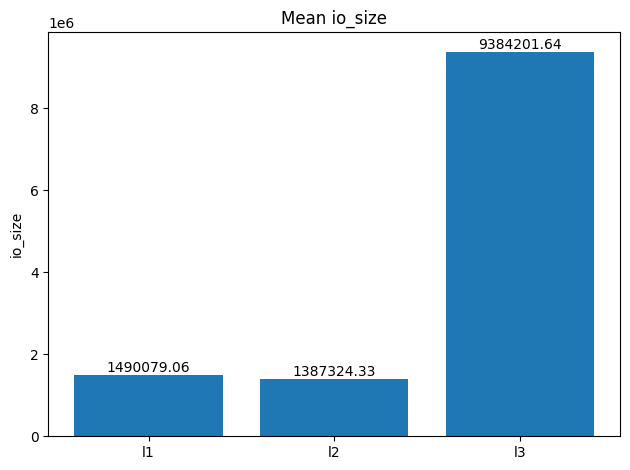

In [62]:
def plot_means(metric):
    vals = [mean_scalar(l1, metric), mean_scalar(l2, metric), mean_scalar(l3, metric)]
    plt.figure()
    plt.bar(labels, vals)
    plt.title(f"Mean {metric}")
    plt.ylabel(metric)
    for i, v in enumerate(vals):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

# usage:
plot_means("io_size")


In [65]:
import networkx as nx

def build_io_graph(df, weight_col="io_time"):
    """
    Build a directed weighted NetworkX graph from dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: fhash, hostname, prod, cons, io_time, io_count, io_size, iops, bw
    weight_col : str, default="io_time"
        Column to use as edge weight (must be in dataframe)

    Rules
    -----
      - If prod == 0:   src = fhash,    dest = hostname
      - If cons == 0:   src = hostname, dest = fhash

    Edge attributes
    ---------------
      io_time, io_count, io_size, iops, bw, weight
    """
    G = nx.DiGraph()

    for _, row in df.iterrows():
        if row["prod"] == 0:
            src, dest = row["fhash"], row["hostname"]
        elif row["cons"] == 0:
            src, dest = row["hostname"], row["fhash"]
        else:
            continue

        # build edge with selected weight
        G.add_edge(
            src, dest,
            weight=row[weight_col],
            io_time=row["io_time"],
            io_count=row["io_count"],
            io_size=row["io_size"],
            iops=row["iops"],
            bw=row["bw"]
        )

    return G

def build_io_graph2(df, weight_col="io_time"):
    """
    Build a directed weighted NetworkX graph from dataframe.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: fhash, hostname, prod, cons, io_time, io_count, io_size, iops, bw
    weight_col : str, default="io_time"
        Column to use as edge weight (must be in dataframe)

    Rules
    -----
      - If prod == 0:   src = fhash,    dest = hostname
      - If cons == 0:   src = hostname, dest = fhash

    Edge attributes
    ---------------
      io_time, io_count, io_size, iops, bw, weight
    """
    G = nx.DiGraph()

    for _, row in df.iterrows():
        if row["prod"] == 0:
            src, dest = row["fhash"], row["pid"]
        elif row["cons"] == 0:
            src, dest = row["pid"], row["fhash"]
        else:
            continue

        # build edge with selected weight
        G.add_edge(
            src, dest,
            weight=row[weight_col],
            io_time=row["io_time"],
            io_count=row["io_count"],
            io_size=row["io_size"],
            iops=row["iops"],
            bw=row["bw"]
        )

    return G

In [66]:
G3 = build_io_graph(l3)
G2 = build_io_graph2(l2)

In [67]:
G3.number_of_edges()

4927

In [68]:
weak_comps = list(nx.weakly_connected_components(G3))
# sizes of each component
sizes = [len(c) for c in weak_comps]
print("Number of weakly connected components:", len(weak_comps))
print("Sizes of weakly connected components:", sizes)
print("Largest weakly connected component size:", max(sizes) if sizes else 0)

#For L3
weak_comps = list(nx.weakly_connected_components(G2))
# sizes of each component
sizes = [len(c) for c in weak_comps]
print("Number of weakly connected components:", len(weak_comps))
print("Sizes of weakly connected components:", sizes)
print("Largest weakly connected component size:", max(sizes) if sizes else 0)

Number of weakly connected components: 1
Sizes of weakly connected components: [2627]
Largest weakly connected component size: 2627
Number of weakly connected components: 4637
Sizes of weakly connected components: [3, 28, 5565, 11, 38, 2, 11, 2, 5, 8, 5, 2, 65, 12, 5, 2, 2, 6, 8, 4, 2, 3, 3, 2, 2, 2, 2, 2, 2, 6, 2, 4, 4, 9, 2, 6, 3, 6, 2, 2, 2, 6, 2, 3, 2, 12, 3, 2, 5, 22, 2, 2, 4, 4, 2, 9, 21, 2, 2, 2, 2, 4, 2, 7, 10, 3, 2, 2, 6, 3, 2, 2, 2, 6, 2, 2, 5, 4, 3, 2, 2, 2, 4, 2, 11, 4, 2, 6, 6, 2, 5, 3, 5, 2, 21, 2, 10, 8, 2, 6, 2, 6, 34, 2, 3, 2, 2, 2, 3, 2, 6, 2, 2, 19, 2, 2, 2, 3, 12, 6, 2, 3, 13, 2, 2, 4, 20, 2, 5, 5, 4, 2, 2, 3, 3, 4, 2, 2, 2, 5, 68, 2, 2, 16, 5, 2, 22, 2, 27, 2, 2, 2, 2, 2, 2, 2, 3, 4, 7, 4, 2, 2, 24, 2, 2, 4, 2, 4, 2, 2, 2, 5, 2, 2, 4, 8, 18, 2, 4, 2, 2, 3, 6, 2, 2, 5, 5, 2, 2, 2, 2, 29, 2, 3, 3, 2, 3, 10, 5, 2, 2, 3, 2, 3, 2, 2, 4, 4, 2, 2, 2, 2, 3, 4, 18, 5, 28, 2, 3, 10, 2, 2, 16, 2, 2, 33, 2, 4, 2, 2, 2, 2, 12, 2, 2, 2, 2, 12, 2, 2, 2, 2, 10, 9, 8, 2, 6, 3, 2, 4

In [ ]:
import networkx as nx

def compute_betweenness(G, weight="weight", normalized=True):
    """
    Compute betweenness centrality of nodes in a directed weighted graph.

    Parameters
    ----------
    G : nx.DiGraph
    weight : str or None, default="weight"
        Edge attribute to use as weight. If None, unweighted.
    normalized : bool, default=True
        Whether to normalize the centrality values.

    Returns
    -------
    dict : {node: centrality_value}
    """
    return nx.betweenness_centrality(G, weight=weight, normalized=normalized)

res = compute_betweenness(G, weight="bw")

In [49]:
res

{39139.0: 0.0,
 'corona203': 0.0,
 56048.0: 0.0,
 'corona200': 0.0005846298915605846,
 21059.0: 0.0,
 46451.0: 0.0,
 16882.0: 0.0,
 51509.0: 0.0,
 3357.0: 0.0,
 12662.0: 0.0,
 33814.0: 0.0,
 32829.0: 0.0,
 46347.0: 0.0,
 'corona201': 0.0,
 52113.0: 0.0,
 'corona198': 0.0,
 17832.0: 0.0,
 26676.0: 0.0,
 22455.0: 0.0,
 17409.0: 0.0,
 2479.0: 0.0,
 55876.0: 0.0,
 55388.0: 0.0,
 13975.0: 0.0,
 35898.0: 0.0,
 11240.0: 0.0,
 64780.0: 0.0,
 12229.0: 0.0,
 59096.0: 0.0,
 59372.0: 0.0,
 13486.0: 0.0,
 35778.0: 0.0,
 26830.0: 0.0,
 30266.0: 0.0,
 14153.0: 0.0,
 48733.0: 0.0,
 33292.0: 0.0,
 12364.0: 0.0,
 18460.0: 0.0,
 49727.0: 0.0,
 57853.0: 0.0,
 11382.0: 0.0,
 534.0: 0.0,
 48279.0: 0.0,
 49690.0: 0.0,
 36498.0: 0.0,
 29312.0: 0.0,
 30460.0: 0.0,
 36365.0: 0.0,
 9114.0: 0.0,
 33792.0: 0.0,
 44717.0: 0.0,
 36642.0: 0.0,
 28072.0: 0.0,
 43963.0: 0.0,
 64056.0: 0.0,
 44255.0: 0.0,
 25758.0: 0.0,
 37147.0: 0.0,
 55240.0: 0.0,
 33309.0: 0.0,
 54018.0: 0.0,
 6209.0: 0.0,
 20009.0: 0.0,
 6712.0: 0.0

In [50]:
top10 = sorted(res.items(), key=lambda x: x[1], reverse=True)[:10]

In [51]:
top10

[('corona200', 0.0005846298915605846),
 (55152.0, 0.0002147027889602147),
 (39139.0, 0.0),
 ('corona203', 0.0),
 (56048.0, 0.0),
 (21059.0, 0.0),
 (46451.0, 0.0),
 (16882.0, 0.0),
 (51509.0, 0.0),
 (3357.0, 0.0)]

In [55]:
l3.query("prod > 0")

,fhash,hostname,prod,cons,hash,mount_point,io_time,io_count,io_size,iops,bw
3202,55152.0,corona200,1,0,55152.0,/p/lustre3,375496,13913,133467865,0.037052,355.444173
4669,65287.0,corona200,1,0,65287.0,/p/lustre3,498219,16315,156504985,0.032747,314.128897


# L2

In [70]:
import networkx as nx

def betweenness_on_largest_cc(G, weight="weight", normalized=True):
    """
    Compute betweenness centrality on the largest weakly connected component.

    Parameters
    ----------
    G : nx.DiGraph
        The original directed graph.
    weight : str or None
        Edge attribute to use as weight.
    normalized : bool
        Normalize betweenness centrality values.

    Returns
    -------
    bc : dict
        {node: betweenness_centrality_value} for nodes in the largest component
    H : nx.DiGraph
        The largest weakly connected component subgraph
    """
    # Get weakly connected components
    comps = list(nx.weakly_connected_components(G))
    if not comps:
        return {}, None

    # Largest component
    largest_cc = max(comps, key=len)

    # Induce subgraph
    H = G.subgraph(largest_cc).copy()

    # Compute betweenness
    bc = nx.betweenness_centrality(H, weight=weight, normalized=normalized)

    return bc, H


bc = betweenness_on_largest_cc(G2,weight="bw")

In [73]:
b,h = bc

In [74]:
top10 = sorted(b.items(), key=lambda x: x[1], reverse=True)[:10]

In [75]:
top10

[(1785246, 1.8415294748746242e-06),
 (5501.0, 1.2923013858769291e-06),
 (1409071, 0.0),
 (57.0, 0.0),
 (32833.0, 0.0),
 (1409104, 0.0),
 (84.0, 0.0),
 (1409113, 0.0),
 (99.0, 0.0),
 (1409132, 0.0)]

In [76]:
l2.query('prod > 0')

,pid,fhash,prod,cons,hash,mount_point,io_time,io_count,io_size,iops,bw
12624,1785246,5501.0,26901,0,5501.0,/proc,438833,16305,156476160,0.037155,356.573366
